# Netflix Content Strategy Analysis

### Notebook Purpose

This notebook contains the step-by-step data cleaning, exploration, visualization, and business analysis for the Netflix content strategy project.

**Note:** Project background, business questions, tools used, and execution instructions are documented in the `README.md` file.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
# Load dataset
df = pd.read_csv("datasets/netflix_data.csv")

# Preview first few rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Overview

In this section, we inspect the dataset structure, columns, data types, and missing values before starting the analysis.

In [3]:
print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (8807, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [6]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## Data Cleaning and Feature Engineering

To prepare the dataset for analysis:
- `date_added` is converted into datetime format
- new time-based features are created
- the first listed country is extracted into a new column called `main_country`

In [7]:
# Convert date column
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Create date-based columns
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["month_name_added"] = df["date_added"].dt.month_name()

# Extract primary country
df["main_country"] = df["country"].str.split(",").str[0].str.strip()

In [8]:
print("Unique content types:", df["type"].dropna().unique())
print("Unique ratings:", df["rating"].dropna().unique())

Unique content types: ['Movie' 'TV Show']
Unique ratings: ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' 'TV-Y7-FV' 'UR']


## 1. Overall Content Mix

We start by comparing the total number of Movies and TV Shows available on Netflix.

In [9]:
content_type_counts = df["type"].value_counts()
content_type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

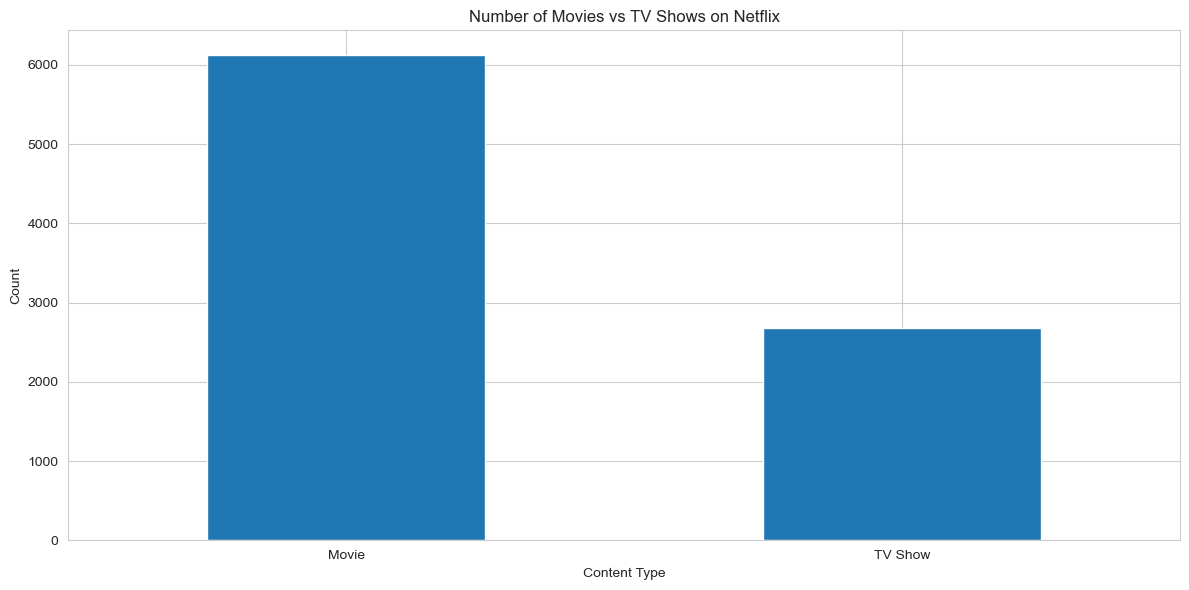

In [10]:
content_type_counts.plot(kind="bar")
plt.title("Number of Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight
Movies dominate the Netflix catalog overall, with a much higher count than TV Shows. This suggests that Netflix's library remains movie-heavy at the overall platform level.

## 2. Movie Release Trends

This section looks at how the number of movies released per year has changed over time.

In [11]:
movies_df = df[df["type"] == "Movie"].copy()
movies_per_year = movies_df["release_year"].value_counts().sort_index()
movies_per_year.tail(20)

release_year
2002     44
2003     51
2004     55
2005     67
2006     82
2007     74
2008    113
2009    118
2010    154
2011    145
2012    173
2013    225
2014    264
2015    398
2016    658
2017    767
2018    767
2019    633
2020    517
2021    277
Name: count, dtype: int64

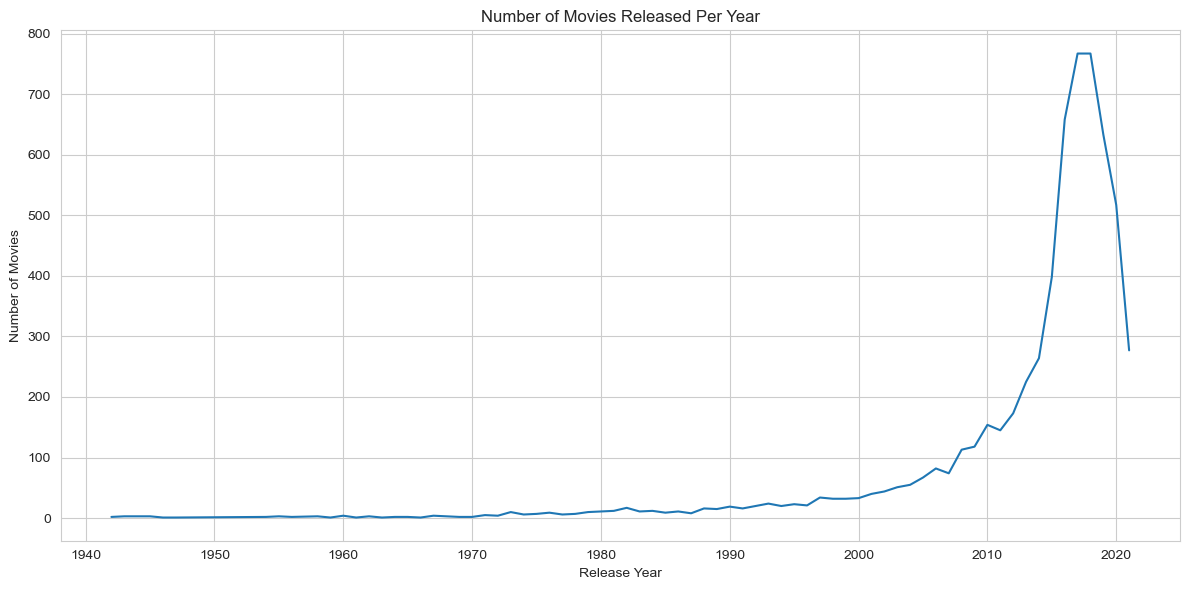

In [12]:
plt.plot(movies_per_year.index, movies_per_year.values)
plt.title("Number of Movies Released Per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

### Insight
The number of movies in the Netflix dataset rises sharply after 2000 and especially during the 2010s. This suggests Netflix's movie library is more concentrated in recent content than older titles.

## 3. Content Added to Netflix Over Time

This analysis uses `year_added` to understand how Netflix expanded its catalog over time.

In [13]:
content_added_by_year = df.groupby(["year_added", "type"]).size().unstack()
content_added_by_year

type,Movie,TV Show
year_added,,
2008.0,1.0,1.0
2009.0,2.0,NaN
2010.0,1.0,NaN
2011.0,13.0,NaN
2012.0,3.0,NaN
2013.0,6.0,4.0
2014.0,19.0,4.0
2015.0,56.0,17.0
2016.0,253.0,165.0


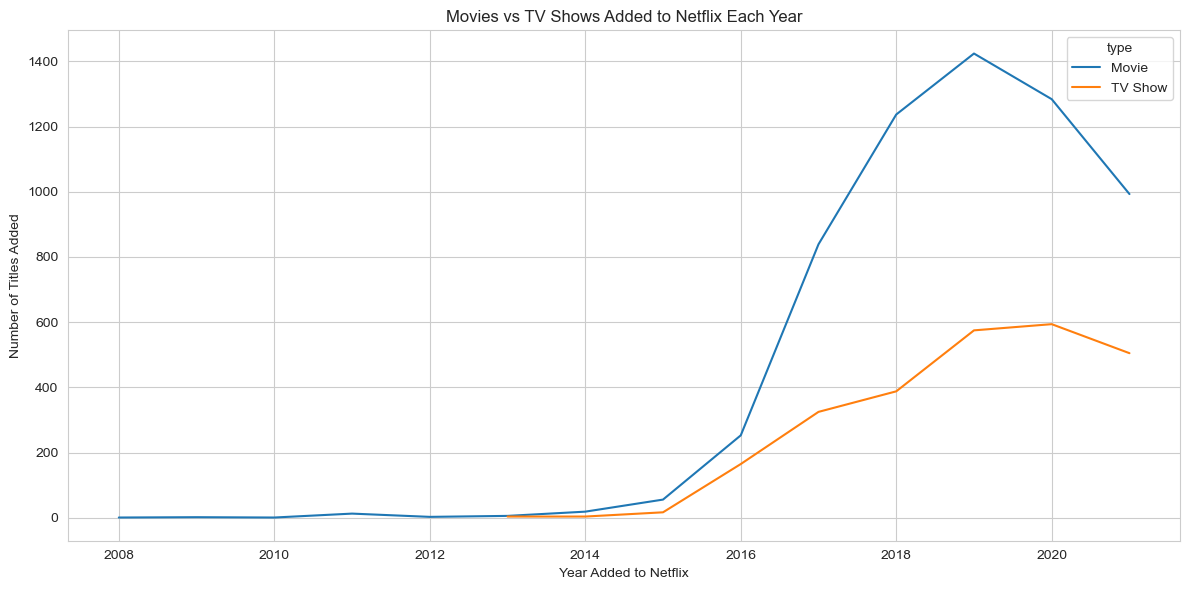

In [14]:
content_added_by_year.plot()
plt.title("Movies vs TV Shows Added to Netflix Each Year")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.show()

### Insight
Both Movies and TV Shows increased strongly after 2015. Movies remain higher than TV Shows in yearly additions, but TV Shows also show steady growth, suggesting Netflix is expanding both formats.

## 4. Country-Level Analysis

This section explores which countries contribute the most titles and how content type differs by country.

In [15]:
top_countries = df["main_country"].value_counts().head(10)
top_countries

main_country
United States     3211
India             1008
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Australia          117
Name: count, dtype: int64

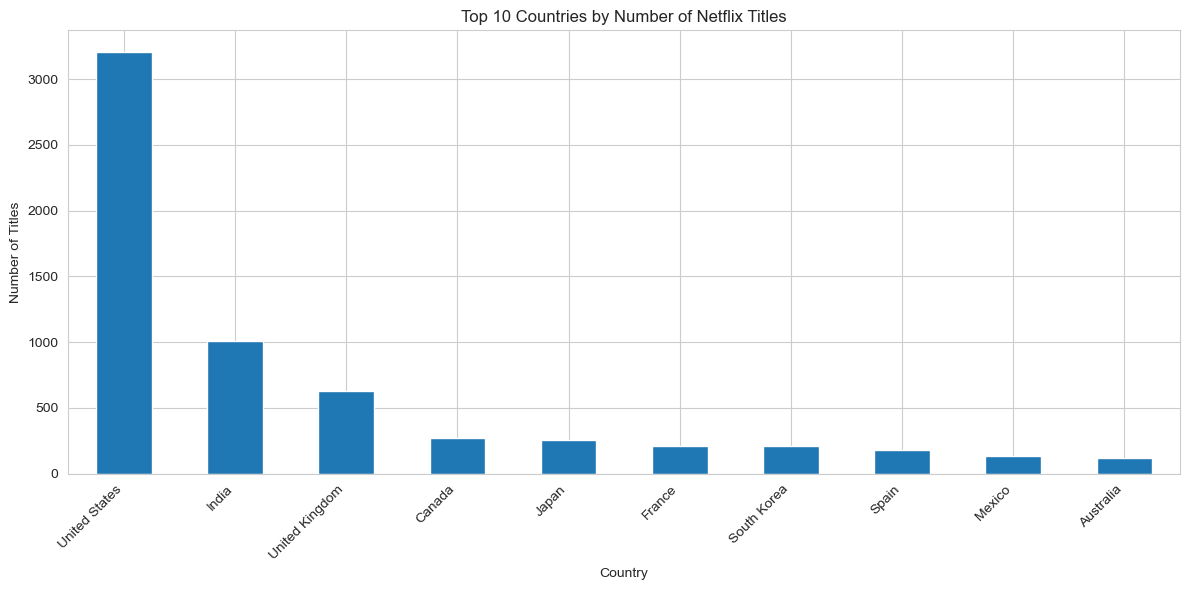

In [16]:
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Insight
The United States has the largest number of titles by far, followed by India and the United Kingdom. This shows that Netflix's library is strongly concentrated in a few major markets.

In [17]:
top_5_countries = df["main_country"].value_counts().head(5).index

country_content_mix = (
    df[df["main_country"].isin(top_5_countries)]
    .groupby(["main_country", "type"])
    .size()
    .unstack()
)

country_content_mix

type,Movie,TV Show
main_country,,
Canada,187,84
India,927,81
Japan,85,174
United Kingdom,382,246
United States,2364,847


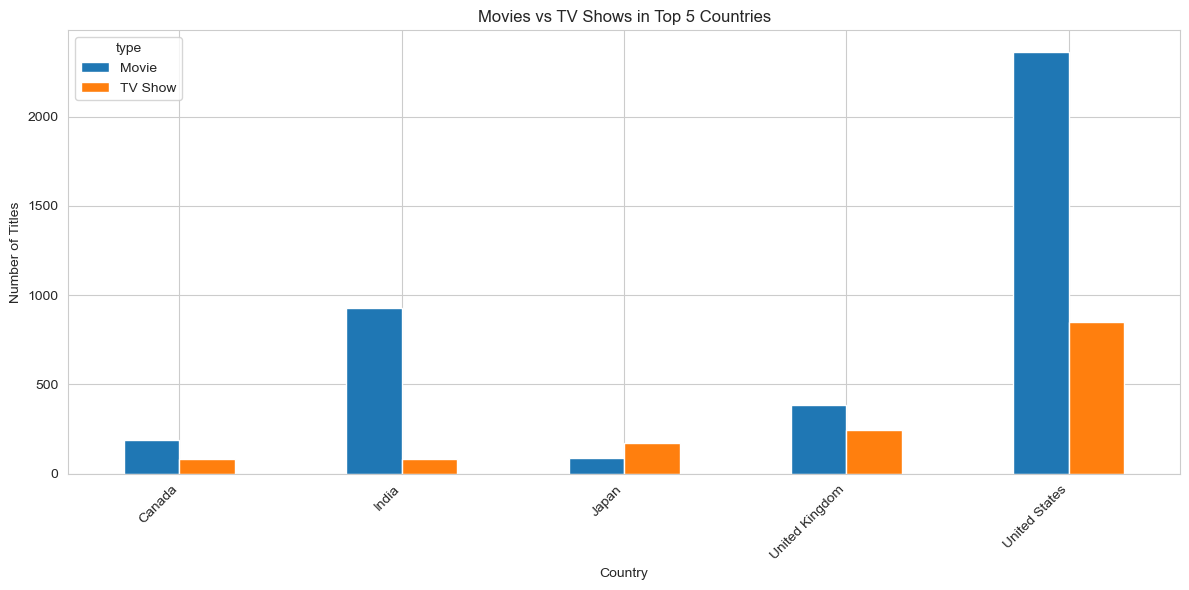

In [18]:
country_content_mix.plot(kind="bar")
plt.title("Movies vs TV Shows in Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Insight
The United States, India, the United Kingdom, and Canada are more movie-heavy, while Japan shows a stronger TV Show presence. This suggests content preferences may vary by market.

## 5. TV Show Additions by Month

This section explores whether some months show stronger TV Show release activity.

In [19]:
tv_shows_df = df[df["type"] == "TV Show"].copy()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

tv_shows_by_month = (
    tv_shows_df["month_name_added"]
    .value_counts()
    .reindex(month_order)
)
tv_shows_by_month

month_name_added
January      181
February     175
March        205
April        209
May          187
June         232
July         254
August       230
September    246
October      210
November     199
December     250
Name: count, dtype: int64

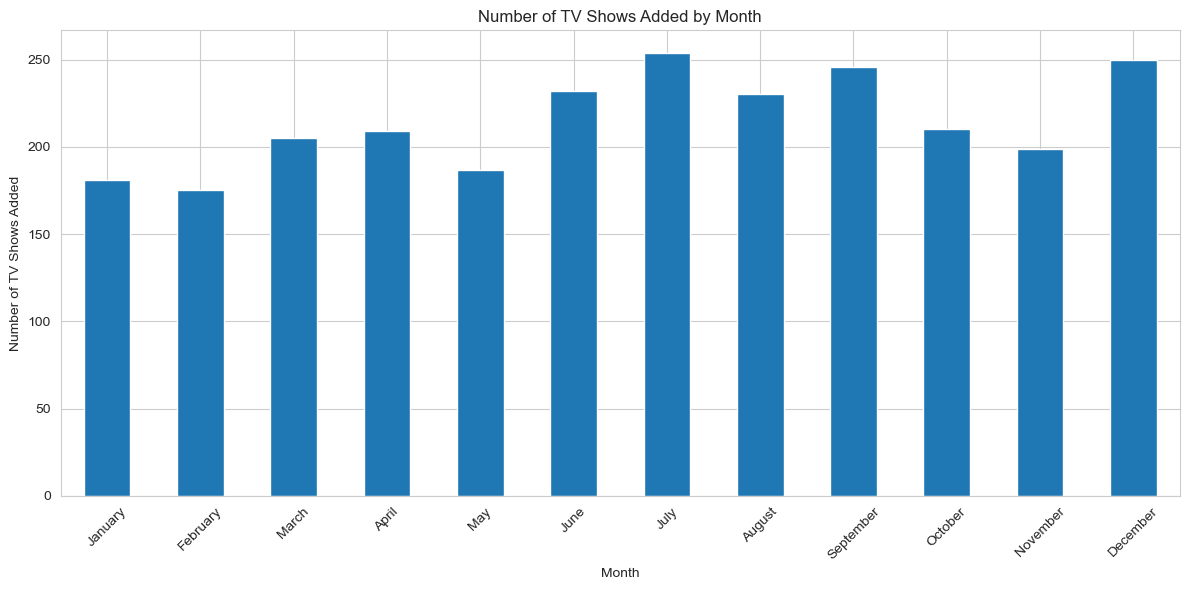

In [20]:
tv_shows_by_month.plot(kind="bar")
plt.title("Number of TV Shows Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of TV Shows Added")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight
TV Shows are added throughout the year, but July, September, and December show relatively higher activity. These months may represent stronger TV content release periods.

## 6. Genre Analysis

Here we analyze the most common genres in the Netflix catalog.

In [21]:
genre_counts = (
    df["listed_in"]
    .str.split(", ", expand=False)
    .explode()
    .value_counts()
    .head(10)
)

genre_counts

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

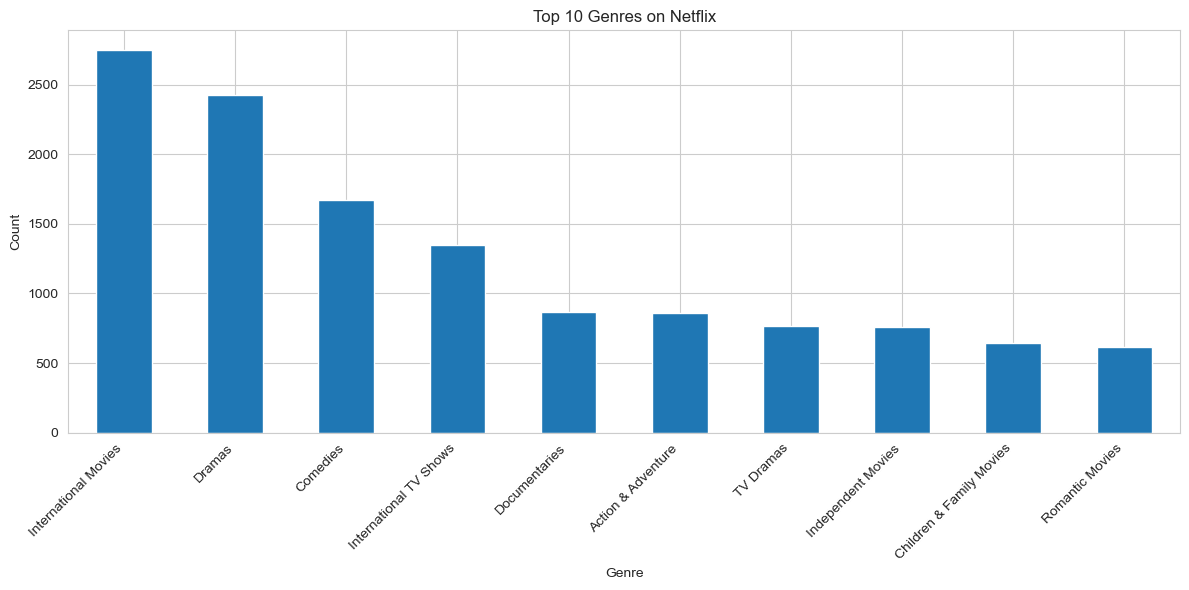

In [22]:
genre_counts.plot(kind="bar")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Insight
International Movies, Dramas, Comedies, and International TV Shows are the most common genres. This suggests Netflix has a strong focus on globally appealing content and broad audience genres.

## 7. Most Frequent Actors

This section identifies actors who appear most frequently in the dataset.

In [23]:
top_actors = (
    df["cast"]
    .dropna()
    .str.split(", ", expand=False)
    .explode()
    .value_counts()
    .head(10)
)

top_actors

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64

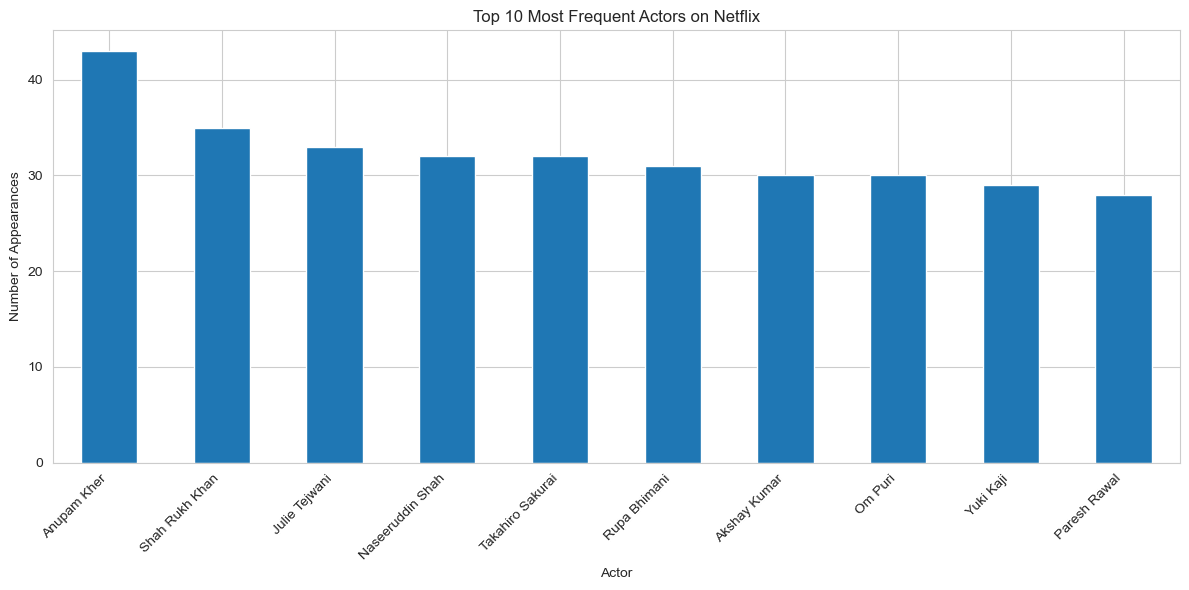

In [24]:
top_actors.plot(kind="bar")
plt.title("Top 10 Most Frequent Actors on Netflix")
plt.xlabel("Actor")
plt.ylabel("Number of Appearances")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Insight
Some actors appear repeatedly across the catalog, including Anupam Kher and Shah Rukh Khan. This further supports the importance of international content in Netflix's library.

## 8. Most Frequent Directors

This section identifies directors who appear most often in the dataset.

In [25]:
top_directors = (
    df["director"]
    .dropna()
    .str.split(", ", expand=False)
    .explode()
    .value_counts()
    .head(10)
)

top_directors

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Name: count, dtype: int64

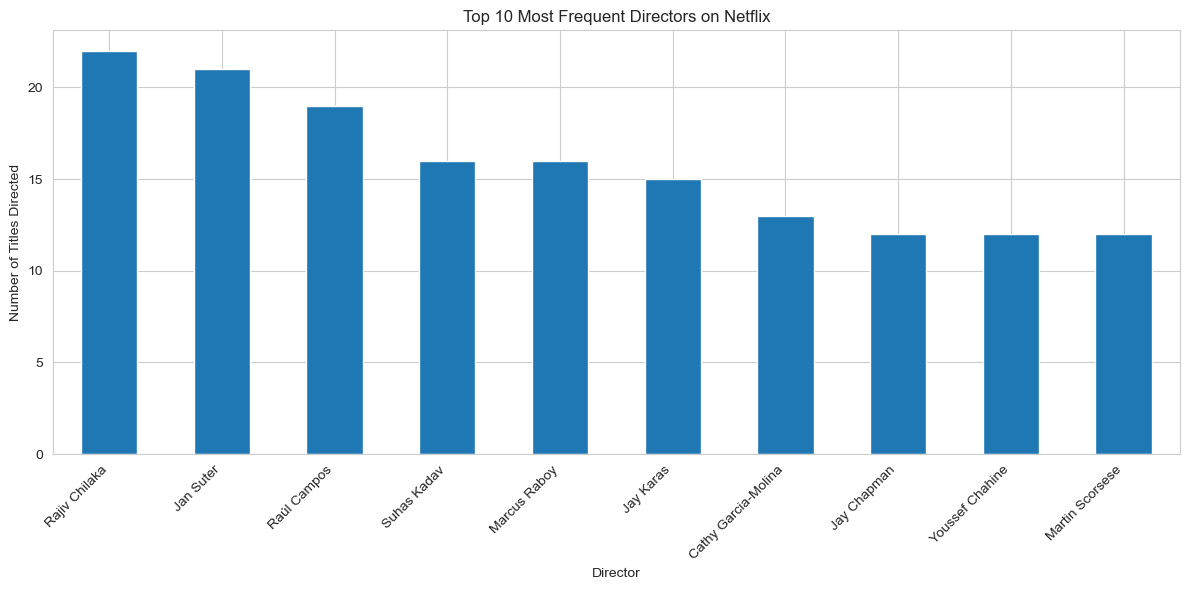

In [26]:
top_directors.plot(kind="bar")
plt.title("Top 10 Most Frequent Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles Directed")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Insight
Some directors appear repeatedly in the dataset, such as Rajiv Chilaka and Jan Suter. This may reflect recurring collaborations or a concentration of titles around certain creators.

## Final Business Insights and Recommendations

### Key Insights
- Movies dominate the overall Netflix catalog.
- Both Movies and TV Shows increased strongly after 2015.
- The catalog is concentrated in a few major markets, especially the United States, India, and the United Kingdom.
- Content mix differs by country, suggesting that audience preferences may vary by region.
- International content is one of Netflix's biggest strengths.
- Drama and Comedy remain core high-volume genres.
- TV Show additions are distributed across the year, with stronger periods such as July, September, and December.
- Some actors and directors appear repeatedly, indicating concentration around recurring talent.

### Recommendations
1. Continue maintaining a strong movie pipeline.
2. Expand TV Shows in a targeted way, especially in markets with stronger series demand.
3. Continue investing in international content.
4. Use more localized content strategy by country.
5. Prioritize broad-appeal genres such as Drama and Comedy.
6. Consider stronger TV launch timing around high-activity months.